In [71]:
#Importing libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#the dataset
df = pd.read_excel('HousePricePrediction.xlsx')
#df = pd.read_excel('HousePricePrediction.xlsx', index_col = 0)
df.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [72]:
#The shape of the data
print('The shape of the data is ', df.shape, '\n')

#Data info
print('Data Inofamtion')
df.info()

The shape of the data is  (2919, 13) 

Data Inofamtion
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [73]:
#Categorise data based on their datatypes
object_cols = df.select_dtypes(include = ['object']).columns
print('Categorical Variables:', len(object_cols))

integer_cols = df.select_dtypes(include = ['int64']).columns
print('Integer Variables:', len(integer_cols))

float_cols = df.select_dtypes(include = ['float']).columns
print('Float Variables:', len(float_cols))

Categorical Variables: 4
Integer Variables: 6
Float Variables: 3


Heatmap saved as correlation_heatmap.png


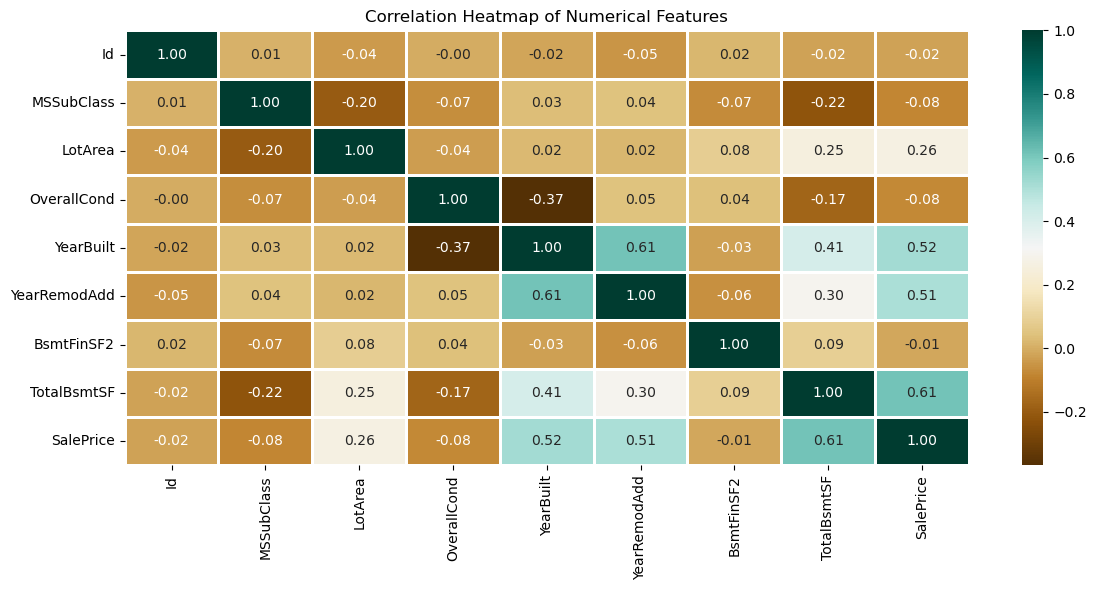

In [74]:
#Visualize the data between int and float columns 
numerical_dataset = df.select_dtypes(include = ['int64', 'float64'])#A dataframe with only numeric values

plt.figure(figsize = (12, 6))
#create a heatmap with color map brown to blue-green
sns.heatmap(numerical_dataset.corr(), cmap = 'BrBG', fmt = '.2f', linewidths = 2, annot = True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('Correlation_heatmap.png')
print('Heatmap saved as correlation_heatmap.png')

<Axes: title={'center': 'No. Uniques values of Categorical Features'}, xlabel='Categorical Features', ylabel='Uniques Values'>

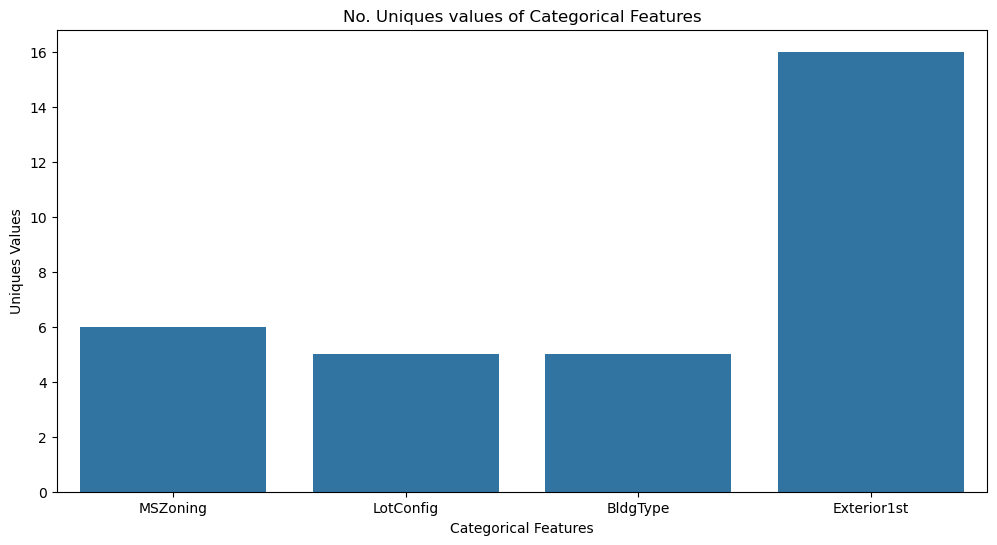

In [75]:
#extracting the unique values in the categorical data
unique_values = []
for col in object_cols:
    unique_values.append(df[col].unique().size)

# visualizing using a bar plot
plt.figure(figsize = (12,6))
plt.title('No. Uniques values of Categorical Features')
plt.xlabel('Categorical Features')
plt.ylabel('Uniques Values')
#plt.xticks(rotation = 90)
sns.barplot(x = object_cols, y = unique_values)

The plot shows that Exterior1st is the highest category with 16 unique values with others having arround 6 unique values

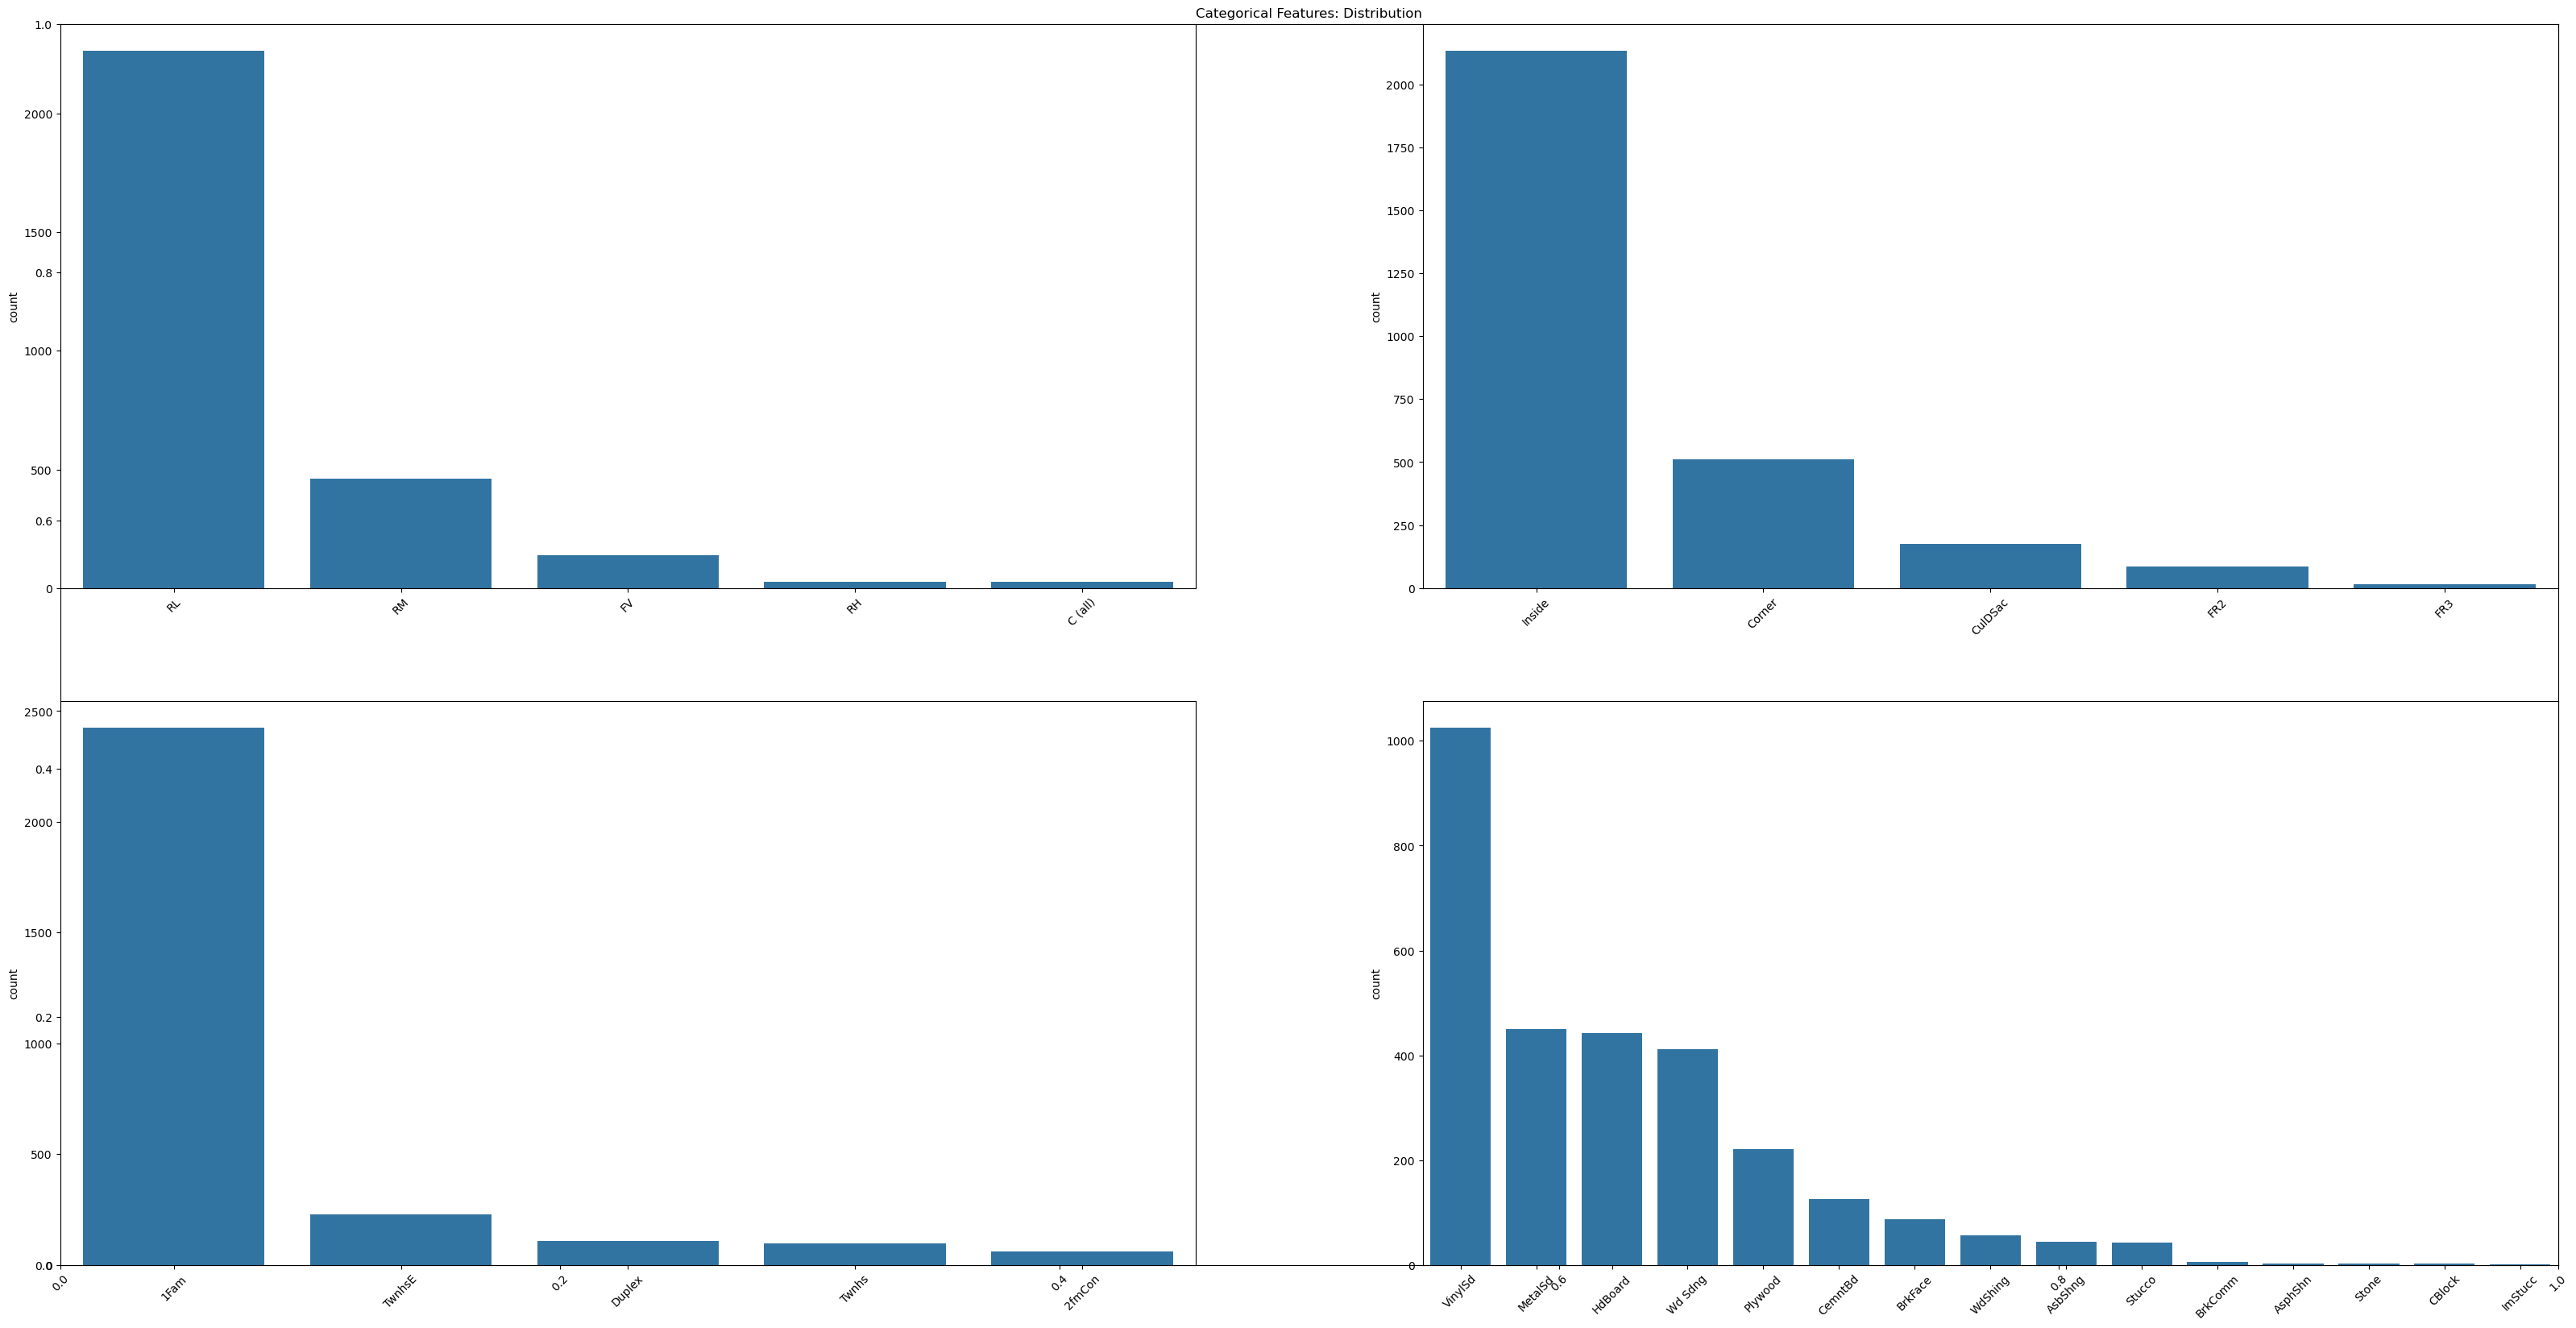

In [76]:
#Find the count of each category
plt.figure(figsize=(40,20))
plt.title('Categorical Features: Distribution')
plt.xticks(rotation = 45)
index = 1
#plt.tight_layout()

for col in object_cols:
    y = df[col].value_counts()
    plt.subplot(2, 2, index)
    plt.xticks(rotation = 45)
    sns.barplot(x = list(y.index), y = y) # x=list(y.index): ensures consistent data type (prevents index object issues)
    index += 1

In [77]:
#Removing irrelevant columns
df.drop(['Id'], axis=1, inplace = True)

In [78]:
#replace empty sales column with their mean values
df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].mean())

In [81]:
#Drop record with null values
new_df = df.dropna()

#check feature with null values
new_df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

The dataset has been cleaned, removing all null values 

In [84]:
#OneHotEncoder is a preprocessing tool in scikit-learn that converts categorical variables
#into a binary (0/1) matrix format that machine learning algorithms can understand.
#import OneHotEncoder to convert categorical values into binary
from sklearn.preprocessing import OneHotEncoder

s = (new_df.dtypes == 'objects') 
objects_cols = list(s[s].index) #converts the categorical feature into a list
print('Categorical Variables:')
print(object_cols)
print('No. of Categorical Features: ', len(object_cols))

Categorical Variables:
Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')
No. of Categorical Features:  4


For the machine learning algorithm to be able to learn this dataset, it should be able to understand it, and so we convert the dataset, especially the categorical feature, into a binary matrix so that it can understand it.

In [86]:
#Apply the OneHotEncoder to the whole dataset
oh_encoder  = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore') # Prevents errors if test data has categories not seen in training 
oh_cols = pd.DataFrame(oh_encoder.fit_transform(new_df[object_cols])) #Learns all unique categories from each column and converts each category to binary (0/1) columns
oh_cols.index = new_df.index #Sets the row index of the encoded DataFrame and uses the same index as the original dataset
oh_cols.columns = oh_encoder.get_feature_names_out() #Returns automatically generated column names from the encoder
df_final = new_df.drop(object_cols, axis = 1) #Removes the original categorical columns from the dataset
df_final = pd.concat([df_final, oh_cols], axis = 1) #oins two DataFrames together horizontally

In [94]:
#import libraries
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Splitting the data into dependent and independent variables
X = df_final.drop(['SalePrice'], axis = 1)
y = df_final['SalePrice']

#Splitting into test and train samples
X_train, X_test, y_train, y_test = train_test_split(X, y, 
        train_size = 0.8, test_size = 0.2, random_state = 0)

Training the first model, the Support Vector Machine model (SVM)

In [95]:
#import of libraries
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

#training the model
model_svm = svm.SVR()
model_svm.fit(X_train, y_train)
y_pred_train = model_svm.predict(X_train)
y_pred_test = model_svm.predict(X_test)

print('MAPE (train): ', mean_absolute_percentage_error(y_train, y_pred_train))
print('MAPE (test): ', mean_absolute_percentage_error(y_test, y_pred_test))

MAPE (train):  0.18079552270780022
MAPE (test):  0.1870512931870423


Training the second model, the Random Forest Regression model

In [100]:
#import library
from sklearn.ensemble import RandomForestRegressor

#Training the model
model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, y_train)
y_pred_train = model_RFR.predict(X_train)
y_pred_test = model_RFR.predict(X_test)

print('MAPE (train): ', mean_absolute_percentage_error(y_train, y_pred_train))
print('MAPE (test): ', mean_absolute_percentage_error(y_test, y_pred_test))

MAPE (train):  0.07425762817752468
MAPE (test):  0.18866402469284557


Training the last model, the Linear Regression model

In [102]:
#import library
from sklearn.linear_model import LinearRegression

#training the model
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)
y_pred_train = model_LR.predict(X_train)
y_pred_test = model_LR.predict(X_test)

print(y_pred_test)

print('MAPE (train): ', mean_absolute_percentage_error(y_train, y_pred_train))
print('MAPE (test): ', mean_absolute_percentage_error(y_test, y_pred_test))

[191650.15923449 256694.21204008 172701.86041707 178271.40635751
 206419.73613526 197732.89101834 122841.48375805 157878.58934738
 191291.77887932 204804.03308353 150243.64027563 219384.08152953
 175255.50575308 146897.11420032 199206.87801954 140385.69033295
 168183.44447516 163859.73646194 199489.97467243 197189.64221705
 196128.98519652 133933.9044786  213384.66385957 171491.85738481
 134813.81633663 155413.33744835 147306.70226194 172544.46498721
 162993.16873967 149133.18652125 165985.90539426 190830.5097074
 163121.19310168 194180.0272962  173858.91795552 196437.34882538
 141050.11569808 164048.62478896 170097.87353521 168791.86980326
 213867.76779934 227566.00767484 225968.66607709 141556.62431201
 200123.25857303 221255.82922142 219628.05092849 112066.6452496
 170881.54038786 195695.22225925 199297.32301991 194250.64094596
 125567.52706621 153150.46411961 197129.20194131 152353.39846162
 135830.20477894 222158.33887991 182830.5698671  199591.81857295
 206995.28102922 167071.636

Comparing the models, the SVM has the leat mean absolute percentage error ans so will be used in out price prediction.